# 1. Understanding the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Successfully imported libraries!")

Successfully imported libraries!


In [2]:
cols = [
    "transaction_id", "price", "date_of_transfer", "postcode",
    "property_type", "old_new", "duration", "paon", "saon",
    "street", "locality", "town_city", "district", "county",
    "ppd_category", "record_status"
]

df = pd.read_csv("../data/pp-monthly-update-new-version.csv",
    names=cols,
    quotechar='"',
    header=None
)

print("Dataset shape:", df.shape)
print()
df.head()

Dataset shape: (101600, 16)



,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category,record_status
0,{5834E4E8-5F54-29C7-E063-4804A8C015BC},330000,2021-06-28 00:00,NW10 0DY,F,N,L,5,FLAT 1,BRAEMAR AVENUE,NaN,LONDON,BRENT,GREATER LONDON,B,A
1,{5834E4E8-5F65-29C7-E063-4804A8C015BC},720000,2021-04-22 00:00,E9 7FL,F,Y,L,35,FLAT 8,SHORE ROAD,NaN,LONDON,HACKNEY,GREATER LONDON,A,A
2,{5834E4E8-631F-29C7-E063-4804A8C015BC},7100000,2021-06-30 00:00,SW1W 8DB,F,Y,L,9,FLAT 3,WHISTLER SQUARE,NaN,LONDON,CITY OF WESTMINSTER,GREATER LONDON,A,A
3,{5834E4E8-633C-29C7-E063-4804A8C015BC},670000,2021-04-14 00:00,NW6 5FZ,F,Y,L,ST. DAVIDS HOUSE,FLAT 9,TOLLGATE GARDENS,NaN,LONDON,CITY OF WESTMINSTER,GREATER LONDON,A,A
4,{5834E4E8-6694-29C7-E063-4804A8C015BC},282500,2021-06-28 00:00,LU1 1TY,S,N,F,255,NaN,RUNLEY ROAD,NaN,LUTON,LUTON,LUTON,A,A


In [3]:
df.tail()

,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category,record_status
101595,{559C5AD5-887C-AFE3-E063-4804A8C004A4},171874,2026-06-17 00:00,BA2 0AR,T,N,F,LITTLECOTE,NaN,THE STREET,FARMBOROUGH,BATH,BATH AND NORTH EAST SOMERSET,BATH AND NORTH EAST SOMERSET,A,D
101596,{559C5AD5-38D2-AFE3-E063-4804A8C004A4},50000,2026-01-13 00:00,LA5 8DL,T,N,F,61,NaN,MAIN ROAD,BOLTON LE SANDS,CARNFORTH,LANCASTER,LANCASHIRE,B,D
101597,{559C5AD5-36D5-AFE3-E063-4804A8C004A4},110000,2026-05-14 00:00,PR2 9RH,T,N,F,7,NaN,MARTINFIELD,FULWOOD,PRESTON,PRESTON,LANCASHIRE,A,D
101598,{559C5AD5-79CA-AFE3-E063-4804A8C004A4},185000,2026-06-01 00:00,WS3 2QJ,S,N,F,87,NaN,CENTRAL DRIVE,NaN,WALSALL,WALSALL,WEST MIDLANDS,A,D
101599,{559C5AD5-7A32-AFE3-E063-4804A8C004A4},450000,2026-06-09 00:00,SE3 8HH,S,N,F,135,NaN,HOLBURNE ROAD,NaN,LONDON,GREENWICH,GREATER LONDON,A,D


In [4]:
type(df)

pandas.DataFrame

In [5]:
df.columns

Index(['transaction_id', 'price', 'date_of_transfer', 'postcode',
       'property_type', 'old_new', 'duration', 'paon', 'saon', 'street',
       'locality', 'town_city', 'district', 'county', 'ppd_category',
       'record_status'],
      dtype='str')

In [6]:
df.describe()

,price
count,1.016000e+05
mean,4.159822e+05
std,2.287313e+06
min,1.000000e+02
25%,1.850000e+05
50%,2.850000e+05
75%,4.250000e+05
max,5.692000e+08


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101600 entries, 0 to 101599
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   transaction_id    101600 non-null  str  
 1   price             101600 non-null  int64
 2   date_of_transfer  101600 non-null  str  
 3   postcode          101334 non-null  str  
 4   property_type     101600 non-null  str  
 5   old_new           101600 non-null  str  
 6   duration          101600 non-null  str  
 7   paon              101600 non-null  str  
 8   saon              12925 non-null   str  
 9   street            99723 non-null   str  
 10  locality          39893 non-null   str  
 11  town_city         101600 non-null  str  
 12  district          101600 non-null  str  
 13  county            101600 non-null  str  
 14  ppd_category      101600 non-null  str  
 15  record_status     101600 non-null  str  
dtypes: int64(1), str(15)
memory usage: 24.1 MB


In [8]:
# ============================================================
# 2. DROP COLUMNS THAT CANNOT HELP THE MODEL
# ============================================================
# paon/saon/street are free-text address parts (near-unique per row -> no
# generalisable signal). transaction_id is a UUID.
#
# NOTE: ppd_category and record_status are KEPT for now. They are not model
# features, but they tell us WHICH ROWS are usable:
#   ppd_category  A = full-market-value sale
#                 B = repossession, buy-to-let portfolio, transfer between
#                     related parties -> the price is not a market price
#   record_status A = addition, C = change, D = deletion
# We filter on them in step 4b, then drop them.
df_clean = df.drop(columns=[
    "transaction_id",
    "paon",
    "saon",
    "street",
])

In [9]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 101600 entries, 0 to 101599
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   price             101600 non-null  int64
 1   date_of_transfer  101600 non-null  str  
 2   postcode          101334 non-null  str  
 3   property_type     101600 non-null  str  
 4   old_new           101600 non-null  str  
 5   duration          101600 non-null  str  
 6   locality          39893 non-null   str  
 7   town_city         101600 non-null  str  
 8   district          101600 non-null  str  
 9   county            101600 non-null  str  
 10  ppd_category      101600 non-null  str  
 11  record_status     101600 non-null  str  
dtypes: int64(1), str(11)
memory usage: 15.6 MB


In [10]:
df_clean.shape

(101600, 12)

In [11]:
df_clean.head()

,price,date_of_transfer,postcode,property_type,old_new,duration,locality,town_city,district,county,ppd_category,record_status
0,330000,2021-06-28 00:00,NW10 0DY,F,N,L,NaN,LONDON,BRENT,GREATER LONDON,B,A
1,720000,2021-04-22 00:00,E9 7FL,F,Y,L,NaN,LONDON,HACKNEY,GREATER LONDON,A,A
2,7100000,2021-06-30 00:00,SW1W 8DB,F,Y,L,NaN,LONDON,CITY OF WESTMINSTER,GREATER LONDON,A,A
3,670000,2021-04-14 00:00,NW6 5FZ,F,Y,L,NaN,LONDON,CITY OF WESTMINSTER,GREATER LONDON,A,A
4,282500,2021-06-28 00:00,LU1 1TY,S,N,F,NaN,LUTON,LUTON,LUTON,A,A


In [12]:
# ============================================================
# 3. CLEAN STRING COLUMNS
# ============================================================

string_columns = [
    "postcode",
    "property_type",
    "old_new",
    "duration",
    "locality",
    "town_city",
    "district",
    "county"
]

for col in string_columns:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .astype("string")
            .str.strip()
            .str.upper()
        )

In [13]:
df_clean.head()

,price,date_of_transfer,postcode,property_type,old_new,duration,locality,town_city,district,county,ppd_category,record_status
0,330000,2021-06-28 00:00,NW10 0DY,F,N,L,<NA>,LONDON,BRENT,GREATER LONDON,B,A
1,720000,2021-04-22 00:00,E9 7FL,F,Y,L,<NA>,LONDON,HACKNEY,GREATER LONDON,A,A
2,7100000,2021-06-30 00:00,SW1W 8DB,F,Y,L,<NA>,LONDON,CITY OF WESTMINSTER,GREATER LONDON,A,A
3,670000,2021-04-14 00:00,NW6 5FZ,F,Y,L,<NA>,LONDON,CITY OF WESTMINSTER,GREATER LONDON,A,A
4,282500,2021-06-28 00:00,LU1 1TY,S,N,F,<NA>,LUTON,LUTON,LUTON,A,A


In [14]:
df.duplicated().sum()

np.int64(0)

### Missing Values

In [15]:
df_clean.isnull().sum()

price                   0
date_of_transfer        0
postcode              266
property_type           0
old_new                 0
duration                0
locality            61707
town_city               0
district                0
county                  0
ppd_category            0
record_status           0
dtype: int64

In [16]:
missing = df_clean.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print()

# locality is genuinely optional (property has no named locality)
# -> fill with a placeholder so it stays usable for grouping
df_clean["locality"] = df_clean["locality"].fillna("UNKNOWN")

# postcode: only 266 missing out of ~101k rows -> drop those rows
df_clean = df_clean.dropna(subset=["postcode"]).reset_index(drop=True)

print("After handling missing values:")
print("Total missing remaining:", df_clean.isnull().sum().sum())
print("New shape:", df_clean.shape)


Columns with missing values:
postcode      266
locality    61707
dtype: int64

After handling missing values:
Total missing remaining: 0
New shape: (101334, 12)


In [17]:
type(df_clean["postcode"])

pandas.Series

In [18]:
type(df_clean["locality"])

pandas.Series

In [19]:
df_clean.isnull().sum()

price               0
date_of_transfer    0
postcode            0
property_type       0
old_new             0
duration            0
locality            0
town_city           0
district            0
county              0
ppd_category        0
record_status       0
dtype: int64

### Converting to Appropriate data types

In [20]:
# ============================================================
# 4. CONVERT DATE
# ============================================================

df_clean["date_of_transfer"] = pd.to_datetime(df_clean["date_of_transfer"], errors="coerce")

# All transfer times are 00:00 -> only the date matters.
# Keep year (trend) and month (seasonality).
df_clean["year"] = df_clean["date_of_transfer"].dt.year
df_clean["month"] = df_clean["date_of_transfer"].dt.month

df_clean[["date_of_transfer", "year", "month"]].head()


,date_of_transfer,year,month
0,2021-06-28,2021,6
1,2021-04-22,2021,4
2,2021-06-30,2021,6
3,2021-04-14,2021,4
4,2021-06-28,2021,6


### Filtering to modellable rows

This is the single highest-impact step in the whole notebook. Without it the model
scores **R² = 0.41**; with it, **R² = 0.70**. Three filters, each with a reason:

| Filter | Why |
|---|---|
| `record_status != 'D'` | `D` rows are *deletions* of previously registered sales — they are corrections, not transactions. |
| `ppd_category == 'A'` | `B` rows (19% of the file) are repossessions, buy-to-let portfolio transfers and sales between related parties. Their prices are **not market prices**, so they are unlearnable noise. |
| `20,000 ≤ price ≤ 5,000,000` | The file contains bulk/commercial transfers up to **£569m**. These are a handful of rows but they dominate squared error entirely. |


In [21]:
# ============================================================
# 4b. FILTER TO FULL-MARKET-VALUE RESIDENTIAL SALES
# ============================================================
MIN_PRICE, MAX_PRICE = 20_000, 5_000_000

before = len(df_clean)
print(f"Rows before filtering: {before:,}\n")

# Show what we are about to remove, so the decision is evidence-based.
print("Price by ppd_category (B is NOT full market value):")
print(df_clean.groupby("ppd_category")["price"].agg(["count", "mean", "median", "max"]).to_string())
print()

step = df_clean[df_clean["record_status"] != "D"]
print(f"  - dropped {before - len(step):,} deletion records (record_status == 'D')")

step2 = step[step["ppd_category"] == "A"]
print(f"  - dropped {len(step) - len(step2):,} non-market sales (ppd_category == 'B')")

df_model = step2[(step2["price"] >= MIN_PRICE) & (step2["price"] <= MAX_PRICE)]
print(f"  - dropped {len(step2) - len(df_model):,} price outliers "
      f"(outside £{MIN_PRICE:,}-£{MAX_PRICE:,})")

# ppd_category / record_status have done their job -> they are not features.
df_model = df_model.drop(columns=["ppd_category", "record_status"]).reset_index(drop=True)

print(f"\nRows after filtering: {len(df_model):,}  ({len(df_model)/before:.1%} retained)")
print(f"Price range now: £{df_model['price'].min():,} - £{df_model['price'].max():,}")
print(f"Median price:    £{df_model['price'].median():,.0f}")

Rows before filtering: 101,334

Price by ppd_category (B is NOT full market value):
              count           mean    median        max
ppd_category                                           
A             82341  376710.511969  295000.0  200000000
B             18993  575688.490128  217115.0  569200000

  - dropped 1,510 deletion records (record_status == 'D')
  - dropped 18,659 non-market sales (ppd_category == 'B')
  - dropped 99 price outliers (outside £20,000-£5,000,000)

Rows after filtering: 81,066  (80.0% retained)
Price range now: £20,000 - £4,975,000
Median price:    £297,000


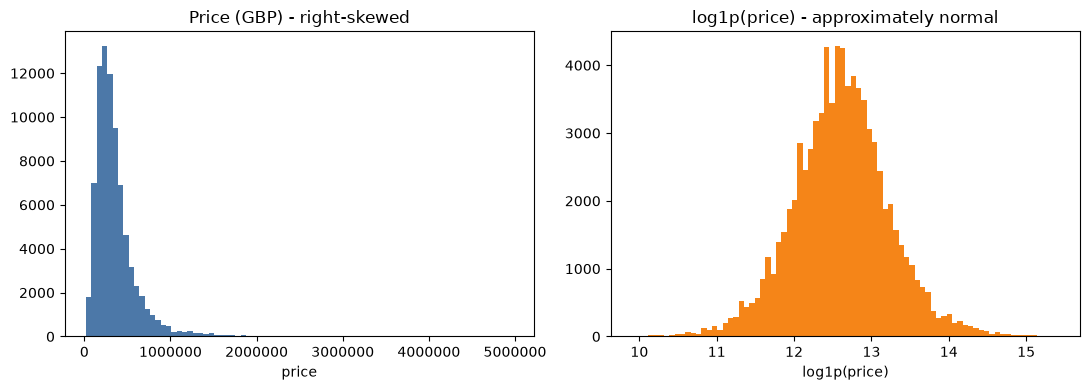

skew  raw price : 4.325
skew  log1p     : 0.072


,price,date_of_transfer,postcode,property_type,old_new,duration,locality,town_city,district,county,year,month
0,720000,2021-04-22,E9 7FL,F,Y,L,UNKNOWN,LONDON,HACKNEY,GREATER LONDON,2021,4
1,670000,2021-04-14,NW6 5FZ,F,Y,L,UNKNOWN,LONDON,CITY OF WESTMINSTER,GREATER LONDON,2021,4
2,282500,2021-06-28,LU1 1TY,S,N,F,UNKNOWN,LUTON,LUTON,LUTON,2021,6
3,200000,2021-08-23,RG4 8EQ,F,N,L,CAVERSHAM,READING,READING,READING,2021,8
4,799995,2021-01-29,MK16 9FU,D,Y,F,SHERINGTON,NEWPORT PAGNELL,MILTON KEYNES,MILTON KEYNES,2021,1


In [22]:
# Price is strongly right-skewed even after filtering -> we train on log1p(price).
# A log target makes the model optimise *relative* error, which is what matters
# for prices, and stops expensive properties dominating the loss.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_model["price"], bins=80, color="#4C78A8")
axes[0].set_title("Price (GBP) - right-skewed")
axes[0].set_xlabel("price")
axes[0].ticklabel_format(style="plain", axis="x")

axes[1].hist(np.log1p(df_model["price"]), bins=80, color="#F58518")
axes[1].set_title("log1p(price) - approximately normal")
axes[1].set_xlabel("log1p(price)")

plt.tight_layout()
plt.show()

print("skew  raw price :", round(float(df_model["price"].skew()), 3))
print("skew  log1p     :", round(float(np.log1p(df_model["price"]).skew()), 3))
df_model.head()

In [23]:
df_model.to_csv("../data/pp-monthly-update-cleaned.csv", index=False)
print(f"Saved cleaned dataset: {len(df_model):,} rows -> ../data/pp-monthly-update-cleaned.csv")

Saved cleaned dataset: 81,066 rows -> ../data/pp-monthly-update-cleaned.csv


# 2. Prepared dataset for model Training

In [24]:
# ============================================================
# 5. FEATURE ENGINEERING & PREPROCESSING
# ============================================================
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

# ---- 5.1 Drop the raw date column (year/month already extracted) ----
df_model = df_model.drop(columns=["date_of_transfer"])

# ---- 5.2 Split the postcode into three NESTED geographic levels ----
# "NW10 0DY"  ->  area "NW"  |  area_code (outward) "NW10"  |  sector "NW10 0"
# Nesting matters: when a fine-grained code is rare or unseen at prediction time,
# the model still has the coarser levels to fall back on.
postcode = df_model["postcode"].astype(str).str.strip().str.upper()
df_model["area_code"] = postcode.str.split().str[0]
df_model["area"]      = postcode.str.extract(r"^([A-Z]+)")[0]
df_model["sector"]    = postcode.str.replace(r"^(\S+)\s(\d).*", r"\1 \2", regex=True)

print("Geographic granularity (number of distinct values):")
for col in ["county", "area", "town_city", "district", "area_code", "sector"]:
    print(f"  {col:12s} {df_model[col].nunique():>6,}")

# ---- 5.3 Assemble feature sets ----
target = "price"
low_card_cats  = ["property_type", "old_new", "duration"]                          # one-hot
num_cols       = ["year", "month"]                                                 # scale
high_card_cats = ["town_city", "district", "county", "area", "area_code", "sector"]  # target-encode

feature_cols = low_card_cats + num_cols + high_card_cats
X = df_model[feature_cols]
y = df_model[target]   # price in GBP

print(f"\nModel features ({len(feature_cols)}): {feature_cols}")
print(f"Rows: {len(X):,}")

# ---- 5.4 Preprocessing pipeline ----
# WHY TargetEncoder and not OneHotEncoder for location?
#   One-hot on town_city + area_code produced ~989 sparse columns. That is slow,
#   memory-hungry (it crashed the kernel on RandomForest) and it scored ~0.18 R2
#   LOWER, because each location became an isolated indicator with no ordering.
#   TargetEncoder replaces each location with a smoothed mean of log-price, giving
#   the trees one dense, ordered, highly informative column per level.
#
# Leakage safety: TargetEncoder cross-fits internally during fit_transform, so a
# row's encoding is computed from OTHER folds, never from its own target. The whole
# ColumnTransformer is inside the Pipeline, so it is fitted on TRAIN ONLY.
preprocessor = ColumnTransformer(transformers=[
    ("num",  StandardScaler(), num_cols),
    ("low",  OneHotEncoder(handle_unknown="ignore"), low_card_cats),
    ("high", TargetEncoder(target_type="continuous", random_state=42), high_card_cats),
])

preprocessor

Geographic granularity (number of distinct values):
  county          114
  area            105
  town_city     1,121
  district        320
  area_code     2,246
  sector        7,829

Model features (11): ['property_type', 'old_new', 'duration', 'year', 'month', 'town_city', 'district', 'county', 'area', 'area_code', 'sector']
Rows: 81,066


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

Numeric correlation with price (Pearson):
price    1.000000
year     0.064370
month   -0.032881


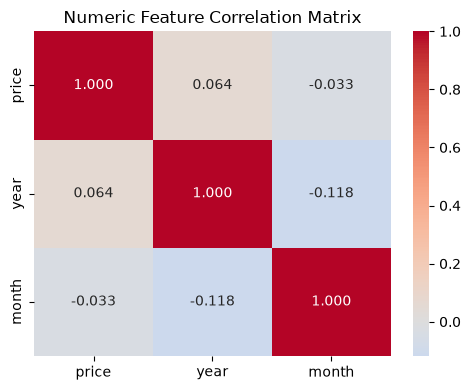


Correlation ratio (eta^2) vs log-price - share of variance explained:
sector           0.5173
area_code        0.4194
town_city        0.3573
district         0.3312
area             0.2889
county           0.2868
property_type    0.1448
duration         0.0399
old_new          0.0057


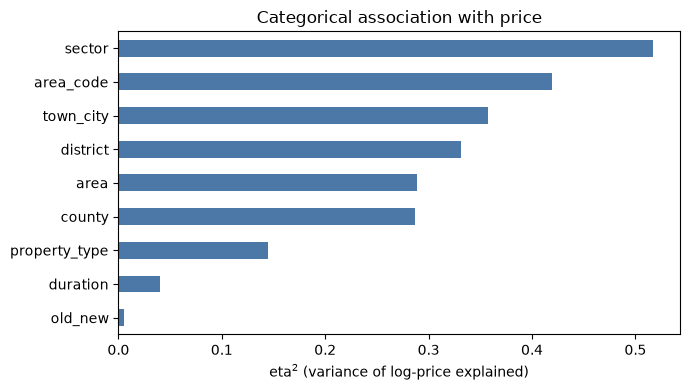


Median price by property type:
                 count    median      mean
property_type                             
Detached         21766  415000.0  501327.0
Semi-detached    24563  275000.0  327667.0
Terraced         21230  240000.0  303682.0
Flat/Maisonette  13507  238000.0  313897.0


In [25]:
# ============================================================
# 6. CORRELATION / ASSOCIATION ANALYSIS
# ============================================================
import seaborn as sns

# ---- 6.1 Numeric correlations (Pearson) ----
# Note: `year` looks weak here because ~96% of the file is 2025-2026, so there is
# almost no time variation left to correlate with. Date is a weak feature in this
# dataset; location and property type carry nearly all the signal.
num_features = ["price", "year", "month"]
corr_matrix = df_model[num_features].corr()
print("Numeric correlation with price (Pearson):")
print(corr_matrix["price"].sort_values(ascending=False).to_string())

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".3f")
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout(); plt.show()

# ---- 6.2 Categoricals vs price: correlation ratio (eta squared) ----
# Pearson r is NOT valid for categoricals. Eta^2 is the right measure: the share
# of variance in log-price explained by group membership. 0 = no signal, 1 = perfect.
log_price = np.log1p(df_model["price"])
grand_mean = log_price.mean()
total_ss = float(((log_price - grand_mean) ** 2).sum())

print("\nCorrelation ratio (eta^2) vs log-price - share of variance explained:")
eta_scores = {}
for col in low_card_cats + high_card_cats:
    grouped = log_price.groupby(df_model[col], observed=True)
    between_ss = float((grouped.count() * (grouped.mean() - grand_mean) ** 2).sum())
    eta_scores[col] = between_ss / total_ss

eta = pd.Series(eta_scores).sort_values(ascending=False)
print(eta.round(4).to_string())

plt.figure(figsize=(7, 4))
eta.plot(kind="barh", color="#4C78A8")
plt.gca().invert_yaxis()
plt.xlabel("eta$^2$ (variance of log-price explained)")
plt.title("Categorical association with price")
plt.tight_layout(); plt.show()

# ---- 6.3 Median price by property type ----
print("\nMedian price by property type:")
type_labels = {"D": "Detached", "S": "Semi-detached", "T": "Terraced",
               "F": "Flat/Maisonette", "O": "Other"}
summary = (df_model.groupby("property_type", observed=True)["price"]
           .agg(["count", "median", "mean"])
           .rename(index=type_labels)
           .sort_values("median", ascending=False))
print(summary.round(0).to_string())

In [26]:
# ---- 5.5 Train / test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

# ---- 5.6 Log-transform the target (price is right-skewed) ----
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# Sanity check the preprocessor on the TRAIN split only.
# TargetEncoder needs y, so fit_transform takes both.
train_matrix = preprocessor.fit_transform(X_train, y_train_log)
print(f"Preprocessed training matrix: {train_matrix.shape}")
print(f"  {len(num_cols)} scaled numeric"
      f"  + one-hot of {low_card_cats}"
      f"  + {len(high_card_cats)} target-encoded location columns")
print("\nCompare: one-hot encoding the same location columns produced 989 sparse "
      "columns.\nTarget encoding gives a dense matrix that trains ~5x faster and scores higher.")

Train: 64,852  |  Test: 16,214


Preprocessed training matrix: (64852, 16)
  2 scaled numeric  + one-hot of ['property_type', 'old_new', 'duration']  + 6 target-encoded location columns

Compare: one-hot encoding the same location columns produced 989 sparse columns.
Target encoding gives a dense matrix that trains ~5x faster and scores higher.


# 3.  Model Training 

In [27]:
# ============================================================
# 7. CONSISTENT MODEL EVALUATION FRAMEWORK
# ============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# One helper used for EVERY model -> results are directly comparable.
# We report three families of metric:
#   [log scale]  what the model actually optimises
#   [GBP scale]  back-transformed with expm1, so it is interpretable
#   [relative]   MdAPE and hit-rates - the metrics a user of the API cares about
def evaluate_model(model, X_train, y_train_log, X_test, y_test_log, model_name):
    import time
    started = time.time()
    model.fit(X_train, y_train_log)
    fit_seconds = time.time() - started

    pred_log = model.predict(X_test)
    pred, actual = np.expm1(pred_log), np.expm1(y_test_log)
    ape = np.abs(pred - actual) / actual          # absolute percentage error

    train_r2 = r2_score(y_train_log, model.predict(X_train))
    test_r2  = r2_score(y_test_log, pred_log)

    result = {
        "model": model_name,
        "R2_log":   test_r2,
        "RMSE_log": float(np.sqrt(mean_squared_error(y_test_log, pred_log))),
        "MAE_log":  float(mean_absolute_error(y_test_log, pred_log)),
        "R2_GBP":   float(r2_score(actual, pred)),
        "MAE_GBP":  float(mean_absolute_error(actual, pred)),
        "MdAPE_%":  float(np.median(ape) * 100),
        "within_10%": float((ape <= 0.10).mean() * 100),
        "within_20%": float((ape <= 0.20).mean() * 100),
        "train_R2": float(train_r2),
        "gap":      float(train_r2 - test_r2),
        "fit_s":    round(fit_seconds, 1),
    }

    print(f"{model_name}")
    print(f"  [log scale]  R2={test_r2:.4f}  RMSE={result['RMSE_log']:.4f}  MAE={result['MAE_log']:.4f}")
    print(f"  [GBP scale]  R2={result['R2_GBP']:.4f}  MAE=£{result['MAE_GBP']:,.0f}")
    print(f"  [relative]   MdAPE={result['MdAPE_%']:.1f}%  "
          f"within +/-10%: {result['within_10%']:.1f}%  within +/-20%: {result['within_20%']:.1f}%")
    print(f"  [overfit]    train R2={train_r2:.4f} vs test R2={test_r2:.4f}  gap={result['gap']:.4f}")
    print(f"  [cost]       fitted in {fit_seconds:.1f}s\n")
    return result

# Results container for the final comparison table
results = []

# ---------------- 7.1 RIDGE REGRESSION BASELINE ----------------
# Ridge rather than plain LinearRegression: the target-encoded columns are
# correlated with each other (they are nested geographies), and L2 regularisation
# keeps the coefficients stable under that collinearity.
from sklearn.linear_model import Ridge

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0)),
])

results.append(
    evaluate_model(ridge_model, X_train, y_train_log, X_test, y_test_log, "Ridge")
)

Ridge
  [log scale]  R2=0.6403  RMSE=0.3759  MAE=0.2781
  [GBP scale]  R2=0.4754  MAE=£107,103
  [relative]   MdAPE=20.8%  within +/-10%: 26.3%  within +/-20%: 48.4%
  [overfit]    train R2=0.6713 vs test R2=0.6403  gap=0.0310
  [cost]       fitted in 0.5s



In [28]:
# ---------------- 7.2 RANDOM FOREST ----------------
# Captures non-linear interactions (property type x area) that a linear model
# cannot express. min_samples_leaf=3 keeps the trees from memorising single sales.
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42,
    )),
])

results.append(
    evaluate_model(rf_model, X_train, y_train_log, X_test, y_test_log, "RandomForest")
)

RandomForest
  [log scale]  R2=0.6926  RMSE=0.3476  MAE=0.2555
  [GBP scale]  R2=0.5851  MAE=£97,246
  [relative]   MdAPE=18.9%  within +/-10%: 28.7%  within +/-20%: 52.2%
  [overfit]    train R2=0.7603 vs test R2=0.6926  gap=0.0678
  [cost]       fitted in 45.0s



In [29]:
# ---------------- 7.3 HISTOGRAM GRADIENT BOOSTING ----------------
# HistGradientBoostingRegressor, not the classic GradientBoostingRegressor:
# the classic one is exact-split and takes many minutes on 65k x 989 features,
# while the histogram version bins the features first and fits in seconds.
#
# early_stopping holds out 10% of TRAIN internally and stops adding trees once
# validation loss stops improving, so max_iter=800 is a ceiling, not a target.
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", HistGradientBoostingRegressor(
        max_iter=800,
        learning_rate=0.06,
        max_leaf_nodes=63,
        min_samples_leaf=20,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42,
    )),
])

results.append(
    evaluate_model(hgb_model, X_train, y_train_log, X_test, y_test_log, "HistGradientBoosting")
)

print(f"Trees actually built before early stopping: "
      f"{hgb_model.named_steps['regressor'].n_iter_}")

HistGradientBoosting
  [log scale]  R2=0.6996  RMSE=0.3435  MAE=0.2528
  [GBP scale]  R2=0.5835  MAE=£96,991
  [relative]   MdAPE=18.6%  within +/-10%: 28.8%  within +/-20%: 52.9%
  [overfit]    train R2=0.7386 vs test R2=0.6996  gap=0.0390
  [cost]       fitted in 12.6s

Trees actually built before early stopping: 431


Consistent comparison (sorted by log-scale R2):
                      R2_log  RMSE_log  MAE_log  R2_GBP      MAE_GBP  MdAPE_%  within_10%  within_20%  train_R2     gap  fit_s
model                                                                                                                         
HistGradientBoosting  0.6996    0.3435   0.2528  0.5835   96991.2075  18.6447     28.8269     52.8926    0.7386  0.0390   12.6
RandomForest          0.6926    0.3476   0.2555  0.5851   97246.3727  18.8978     28.6913     52.1956    0.7603  0.0678   45.0
Ridge                 0.6403    0.3759   0.2781  0.4754  107103.1856  20.7924     26.3291     48.4026    0.6713  0.0310    0.5

Best model: HistGradientBoosting  (test R2 log = 0.6996, MdAPE = 18.6%, overfit gap = 0.0390)


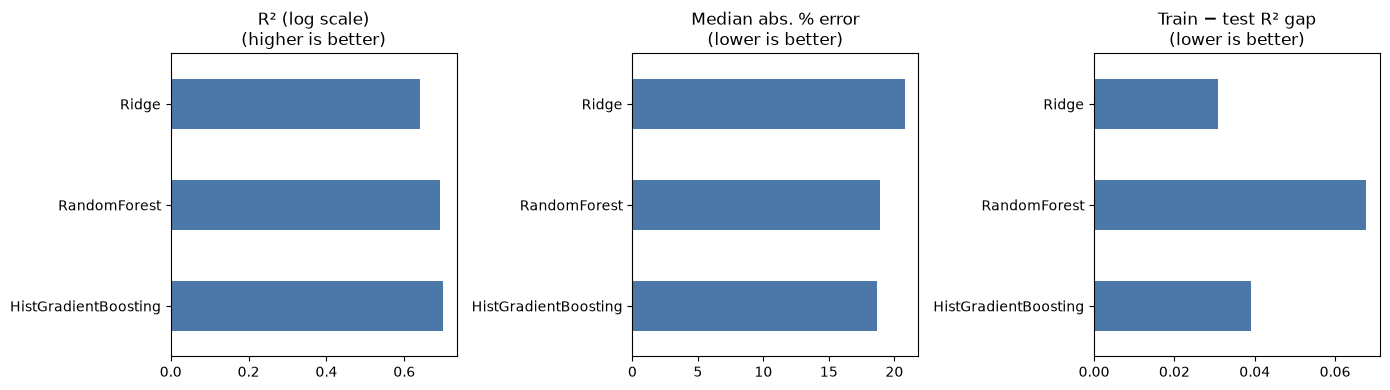

In [30]:
# ============================================================
# 8. MODEL COMPARISON & SELECTION
# ============================================================
fitted_models = {
    "Ridge": ridge_model,
    "RandomForest": rf_model,
    "HistGradientBoosting": hgb_model,
}

results_df = pd.DataFrame(results).set_index("model").sort_values("R2_log", ascending=False)
print("Consistent comparison (sorted by log-scale R2):")
print(results_df.round(4).to_string())

best_name  = results_df.index[0]
best_model = fitted_models[best_name]
best_r2    = results_df["R2_log"].iloc[0]
print(f"\nBest model: {best_name}  (test R2 log = {best_r2:.4f}, "
      f"MdAPE = {results_df['MdAPE_%'].iloc[0]:.1f}%, "
      f"overfit gap = {results_df['gap'].iloc[0]:.4f})")

# ---- 8.1 Visual comparison ----
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (metric, label, better) in zip(axes, [
    ("R2_log", "R² (log scale)", "higher is better"),
    ("MdAPE_%", "Median abs. % error", "lower is better"),
    ("gap", "Train − test R² gap", "lower is better"),
]):
    results_df[metric].plot(kind="barh", ax=ax, color="#4C78A8")
    ax.set_title(f"{label}\n({better})")
    ax.set_ylabel("")
plt.tight_layout(); plt.show()

# 4. Performance Metrics, Validation and Prediction on New Data

A single train/test split gives **one** number, and that number could be a lucky split.
This section establishes whether the result is real:

1. **5-fold cross-validation** — does the score hold across every slice of the data?
2. **Permutation importance** — which features actually drive the prediction?
3. **Residual analysis** — is the model biased, and *where* does it fail?
4. **Prediction on new data** — an end-to-end check on unseen properties.

5-fold cross-validation of HistGradientBoosting

  fold 1:  R2 = 0.7006
  fold 2:  R2 = 0.6958
  fold 3:  R2 = 0.6878
  fold 4:  R2 = 0.6844
  fold 5:  R2 = 0.6968

  R2   = 0.6931  +/- 0.0060
  RMSE = 0.3469 (log scale)
  MAE  = 0.2550 (log scale)

  hold-out R2 = 0.6996   CV mean R2 = 0.6931   diff = 0.0065
  VERDICT: STABLE - the hold-out score is trustworthy


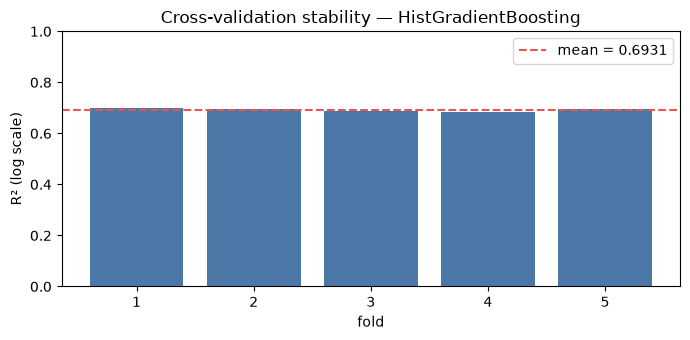

In [31]:
# ============================================================
# 9. 5-FOLD CROSS-VALIDATION
# ============================================================
# The whole Pipeline goes into cross_validate, so the preprocessor (including
# TargetEncoder) is refitted inside every fold. Passing an already-fitted
# preprocessor here would leak the validation fold into the encoding.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_estimator = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", best_model.named_steps["regressor"]),
])

cv_scores = cross_validate(
    cv_estimator, X, np.log1p(y), cv=cv,
    scoring=["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"],
)

fold_r2 = cv_scores["test_r2"]
print(f"5-fold cross-validation of {best_name}\n")
for i, score in enumerate(fold_r2, start=1):
    print(f"  fold {i}:  R2 = {score:.4f}")

print(f"\n  R2   = {fold_r2.mean():.4f}  +/- {fold_r2.std():.4f}")
print(f"  RMSE = {-cv_scores['test_neg_root_mean_squared_error'].mean():.4f} (log scale)")
print(f"  MAE  = {-cv_scores['test_neg_mean_absolute_error'].mean():.4f} (log scale)")

# Does the single hold-out score agree with the cross-validated one?
drift = abs(best_r2 - fold_r2.mean())
tolerance = 2 * fold_r2.std() + 0.01
print(f"\n  hold-out R2 = {best_r2:.4f}   CV mean R2 = {fold_r2.mean():.4f}   diff = {drift:.4f}")
print(f"  VERDICT: {'STABLE - the hold-out score is trustworthy' if drift < tolerance else 'UNSTABLE - investigate the split'}")

plt.figure(figsize=(7, 3.5))
plt.bar(range(1, len(fold_r2) + 1), fold_r2, color="#4C78A8")
plt.axhline(fold_r2.mean(), color="#E45756", linestyle="--",
            label=f"mean = {fold_r2.mean():.4f}")
plt.ylim(0, 1)
plt.xlabel("fold"); plt.ylabel("R² (log scale)")
plt.title(f"Cross-validation stability — {best_name}")
plt.legend(); plt.tight_layout(); plt.show()

Permutation importance - HistGradientBoosting
(drop in R2 when the feature is shuffled)

property_type    0.3659
duration         0.0916
area             0.0897
district         0.0800
area_code        0.0723
year             0.0635
town_city        0.0610
sector           0.0542
county           0.0410
old_new          0.0155
month            0.0018


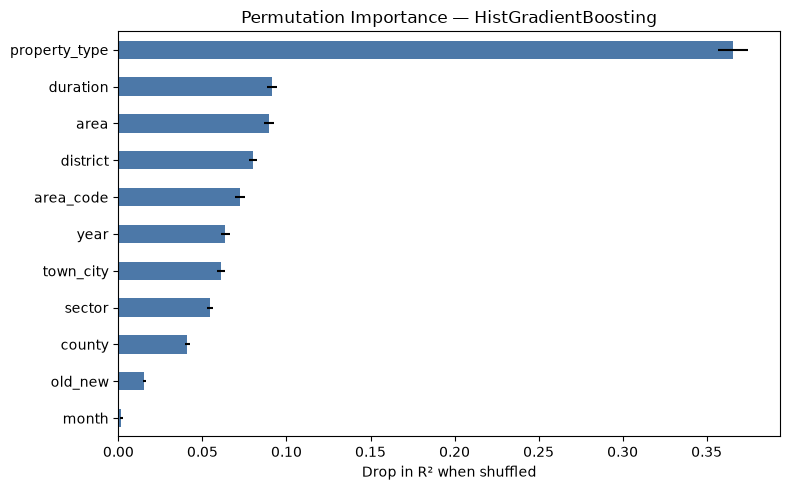

In [32]:
# ============================================================
# 10. PERMUTATION IMPORTANCE
# ============================================================
# HistGradientBoosting has no .feature_importances_, and impurity-based importance
# is biased towards high-cardinality features anyway. Permutation importance is
# model-agnostic and measures what we actually care about: how much test R2 DROPS
# when a feature's values are shuffled.
from sklearn.inspection import permutation_importance

sample = X_test.sample(6000, random_state=42)          # 6k rows keeps this ~30s
perm = permutation_importance(
    best_model, sample, np.log1p(y_test.loc[sample.index]),
    n_repeats=5, random_state=42, n_jobs=-1, scoring="r2",
)

importance = (pd.Series(perm.importances_mean, index=feature_cols)
              .sort_values(ascending=False))

print(f"Permutation importance - {best_name}")
print("(drop in R2 when the feature is shuffled)\n")
print(importance.round(4).to_string())

plt.figure(figsize=(8, 5))
importance.plot(kind="barh", xerr=pd.Series(perm.importances_std, index=feature_cols)[importance.index],
                color="#4C78A8")
plt.gca().invert_yaxis()
plt.xlabel("Drop in R² when shuffled")
plt.title(f"Permutation Importance — {best_name}")
plt.tight_layout(); plt.show()

Residuals on the log scale:
  mean = +0.0027   (≈0 means the model is UNBIASED - it does not systematically over/under-predict)
  std  = 0.3435


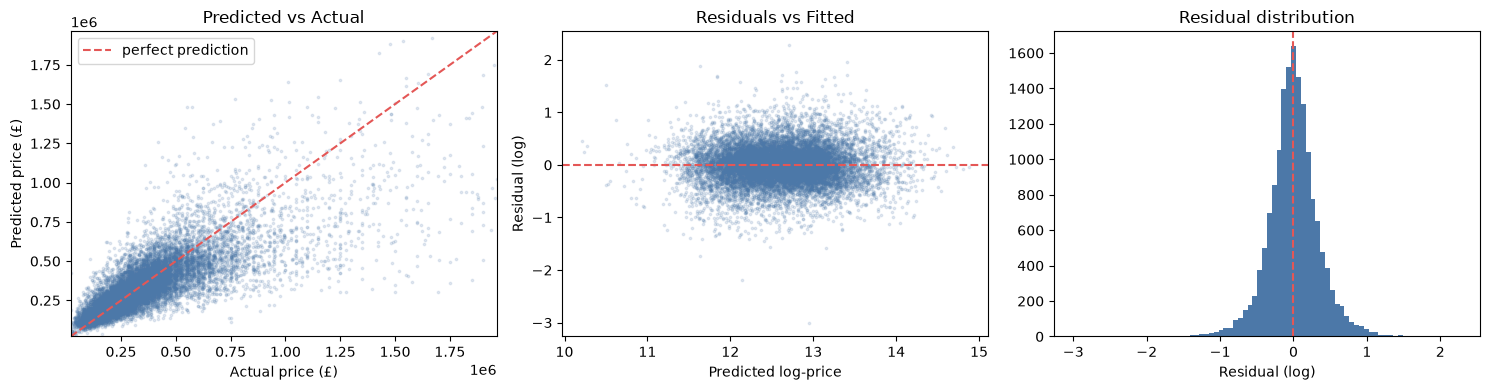


Median absolute % error by price decile:
           n  price_from  price_to  MdAPE
decile                                   
1       1624       20000    139950   38.1
2       1736      139995    185000   18.9
3       1607      185500    225000   15.7
4       1586      225250    260000   15.2
5       1738      260253    300000   15.7
6       1468      301000    345000   14.4
7       1695      345250    400000   15.0
8       1537      400133    480000   15.7
9       1616      481000    645000   19.7
10      1607      645500   4775000   32.6

Median absolute % error by property type:
                    n  MdAPE
property_type               
Detached         4407   20.7
Flat/Maisonette  2729   22.2
Semi-detached    4892   16.0
Terraced         4186   17.8


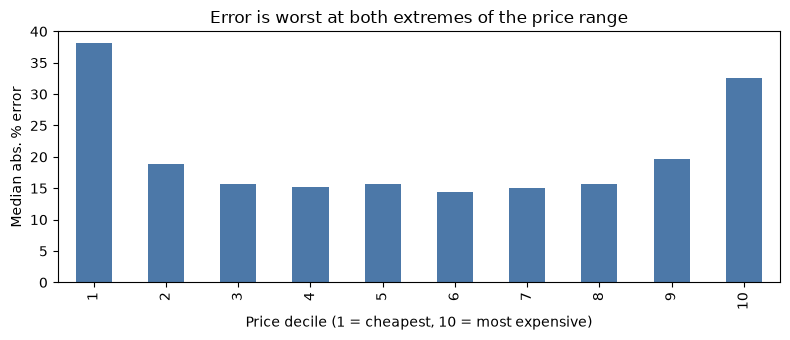

In [33]:
# ============================================================
# 11. RESIDUAL ANALYSIS - WHERE DOES THE MODEL FAIL?
# ============================================================
pred_log = best_model.predict(X_test)
pred     = np.expm1(pred_log)
actual   = y_test.values

errors = pd.DataFrame({
    "actual": actual,
    "predicted": pred,
    "residual_log": np.log1p(actual) - pred_log,
    "ape": np.abs(pred - actual) / actual * 100,
    "property_type": X_test["property_type"].values,
})

print("Residuals on the log scale:")
print(f"  mean = {errors.residual_log.mean():+.4f}   "
      f"(≈0 means the model is UNBIASED - it does not systematically over/under-predict)")
print(f"  std  = {errors.residual_log.std():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Predicted vs actual
axes[0].scatter(actual, pred, s=3, alpha=0.15, color="#4C78A8")
lims = [actual.min(), np.percentile(actual, 99.5)]
axes[0].plot(lims, lims, "--", color="#E45756", label="perfect prediction")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual price (£)"); axes[0].set_ylabel("Predicted price (£)")
axes[0].set_title("Predicted vs Actual"); axes[0].legend()

# Residuals vs fitted - looking for funnels/curves that signal a missing feature
axes[1].scatter(pred_log, errors.residual_log, s=3, alpha=0.15, color="#4C78A8")
axes[1].axhline(0, color="#E45756", linestyle="--")
axes[1].set_xlabel("Predicted log-price"); axes[1].set_ylabel("Residual (log)")
axes[1].set_title("Residuals vs Fitted")

# Residual distribution
axes[2].hist(errors.residual_log, bins=80, color="#4C78A8")
axes[2].axvline(0, color="#E45756", linestyle="--")
axes[2].set_xlabel("Residual (log)"); axes[2].set_title("Residual distribution")

plt.tight_layout(); plt.show()

# ---- Where the error concentrates ----
print("\nMedian absolute % error by price decile:")
errors["decile"] = pd.qcut(errors.actual, 10, labels=False) + 1
by_decile = errors.groupby("decile").agg(
    n=("ape", "size"), price_from=("actual", "min"),
    price_to=("actual", "max"), MdAPE=("ape", "median"),
).round(1)
print(by_decile.to_string())

print("\nMedian absolute % error by property type:")
type_labels = {"D": "Detached", "S": "Semi-detached", "T": "Terraced",
               "F": "Flat/Maisonette", "O": "Other"}
by_type = (errors.groupby("property_type")
           .agg(n=("ape", "size"), MdAPE=("ape", "median"))
           .rename(index=type_labels).round(1))
print(by_type.to_string())

plt.figure(figsize=(8, 3.5))
by_decile["MdAPE"].plot(kind="bar", color="#4C78A8")
plt.xlabel("Price decile (1 = cheapest, 10 = most expensive)")
plt.ylabel("Median abs. % error")
plt.title("Error is worst at both extremes of the price range")
plt.tight_layout(); plt.show()

# 5. Save the Trained Model with joblib

Two things matter when persisting a model:

1. **Save the whole `Pipeline`, never just the regressor.** The preprocessor holds the
   fitted scaler statistics and the learned target encodings. A bare regressor would be
   handed raw strings at serving time and fail.
2. **Refit on 100% of the data first.** The train/test split existed to *measure* quality.
   Now that the measurement is done, the shipped model should learn from every row.

We save a **bundle** — the pipeline plus its metrics and metadata — so the API can report
what it is serving and when it was trained.

In [34]:
# ============================================================
# 12. REFIT ON ALL DATA AND PERSIST WITH JOBLIB
# ============================================================
import joblib
from datetime import datetime, timezone
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "house_price_model.pkl"

# Refit the winning pipeline on the FULL dataset.
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", best_model.named_steps["regressor"]),
])
final_model.fit(X, np.log1p(y))
print(f"Refitted {best_name} on all {len(X):,} rows.")

bundle = {
    "model": final_model,                    # preprocessor + regressor together
    "model_name": best_name,
    "feature_columns": feature_cols,         # exact column order the API must supply
    "target": "log1p(price)",                # remember to expm1() the prediction
    "trained_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "n_rows": int(len(X)),
    "metrics": results_df.loc[best_name].to_dict(),
    "cross_validation": {
        "folds": 5,
        "R2_per_fold": [round(float(s), 4) for s in fold_r2],
        "R2_mean": float(fold_r2.mean()),
        "R2_std": float(fold_r2.std()),
    },
    "log_residual_std": float(errors.residual_log.std()),  # used for prediction intervals
}

joblib.dump(bundle, MODEL_PATH, compress=3)
print(f"Saved -> {MODEL_PATH.resolve()}  ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")

Refitted HistGradientBoosting on all 81,066 rows.


Saved -> D:\House Price Prediction end-to-end\models\house_price_model.pkl  (2.3 MB)


In [35]:
# ============================================================
# 13. RELOAD AND PREDICT ON NEW DATA (end-to-end check)
# ============================================================
# Load the bundle back exactly the way the FastAPI app will, then predict on
# properties described from scratch - proving the artefact works standalone.
loaded = joblib.load(MODEL_PATH)
print(f"Loaded: {loaded['model_name']} trained {loaded['trained_at']} "
      f"on {loaded['n_rows']:,} rows\n")


def predict_price(postcode, property_type, old_new, duration,
                  town_city, district, county, year, month):
    """Build the same features used in training, then predict a price in GBP."""
    pc = postcode.strip().upper()
    row = pd.DataFrame([{
        "property_type": property_type.upper(),
        "old_new": old_new.upper(),
        "duration": duration.upper(),
        "year": year,
        "month": month,
        "town_city": town_city.upper(),
        "district": district.upper(),
        "county": county.upper(),
        "area": pd.Series([pc]).str.extract(r"^([A-Z]+)")[0].iloc[0],
        "area_code": pc.split()[0],
        "sector": pd.Series([pc]).str.replace(r"^(\S+)\s(\d).*", r"\1 \2", regex=True).iloc[0],
    }])[loaded["feature_columns"]]

    log_pred = loaded["model"].predict(row)[0]
    price = float(np.expm1(log_pred))
    # +/- 1 residual sigma in log space -> an asymmetric band in GBP, which is how
    # price uncertainty actually behaves (more headroom above than below).
    sigma = loaded["log_residual_std"]
    return {
        "predicted_price": round(price, 2),
        "lower_bound": round(float(np.expm1(log_pred - sigma)), 2),
        "upper_bound": round(float(np.expm1(log_pred + sigma)), 2),
    }


new_properties = [
    dict(postcode="NW10 0DY", property_type="F", old_new="N", duration="L",
         town_city="LONDON", district="BRENT", county="GREATER LONDON", year=2026, month=6),
    dict(postcode="PR2 9RH", property_type="D", old_new="N", duration="F",
         town_city="PRESTON", district="PRESTON", county="LANCASHIRE", year=2026, month=5),
    dict(postcode="SW1W 8DB", property_type="F", old_new="Y", duration="L",
         town_city="LONDON", district="CITY OF WESTMINSTER", county="GREATER LONDON",
         year=2026, month=6),
    dict(postcode="WS3 2QJ", property_type="S", old_new="N", duration="F",
         town_city="WALSALL", district="WALSALL", county="WEST MIDLANDS", year=2026, month=6),
]

print("Predictions on new, unseen properties:\n")
for prop in new_properties:
    out = predict_price(**prop)
    print(f"  {prop['property_type']} in {prop['town_city']:12s} {prop['postcode']:9s} "
          f"-> £{out['predicted_price']:>10,.0f}   "
          f"(range £{out['lower_bound']:,.0f} - £{out['upper_bound']:,.0f})")

print("\nSanity check: a Westminster new-build flat should out-price a Walsall semi.")

Loaded: HistGradientBoosting trained 2026-09-09T16:11:37+00:00 on 81,066 rows

Predictions on new, unseen properties:

  F in LONDON       NW10 0DY  -> £   367,209   (range £260,443 - £517,743)


  D in PRESTON      PR2 9RH   -> £   303,936   (range £215,566 - £428,532)
  F in LONDON       SW1W 8DB  -> £   747,181   (range £529,938 - £1,053,481)


  S in WALSALL      WS3 2QJ   -> £   228,106   (range £161,784 - £321,615)

Sanity check: a Westminster new-build flat should out-price a Walsall semi.


# 6. FastAPI Web Application

The notebook has done its job: it explored the data, justified the filtering, compared
models and validated the winner. Everything from here lives in **`.py` files**, because
a notebook is not deployable.

The logic was moved out of this notebook into a package so that training and serving
build features with **the same code** — the classic source of "works in the notebook,
wrong in production" bugs:

```
backend_house_prediction/
├── notebooks/house_price_prediction.ipynb   <- you are here
├── src/preprocessing.py   load / clean / feature-engineer (shared by training AND the API)
├── src/train.py           reproduces sections 5-12 as a script, writes models/*.pkl
├── src/predict.py         loads the bundle, turns a request into a price
└── app/main.py            FastAPI endpoints

frontend_house_prediction/                       <- React + Vite client
```

Retrain and serve from the command line (run from `backend_house_prediction/`):

```bash
python -m src.train      # retrain, revalidate, rewrite models/*.pkl
python -m app.main       # serve http://127.0.0.1:8000/docs
```

Host, port, reload and CORS origins come from `backend_house_prediction/.env`
(see `.env.example`). `python -m app.main` is equivalent to
`uvicorn app.main:app --reload`.

**Endpoints**

| Method | Path | Purpose |
|---|---|---|
| `GET`  | `/health`  | is the model loaded, when was it trained, active config |
| `GET`  | `/location/{postcode}` | resolve a postcode to town / district / county |
| `GET`  | `/schema`  | valid category codes, so a client can build a form |
| `GET`  | `/metrics` | the hold-out and cross-validation scores of the deployed model |
| `POST` | `/predict` | price + confidence interval for one property |
| `POST` | `/predict/batch` | up to 500 properties in one call |

# 7. Testing the Application

`TestClient` exercises the real FastAPI app in-process — no server, no ports — so this
runs inside the notebook and in CI alike.

In [36]:
# ============================================================
# 14. EXERCISE THE API IN-PROCESS
# ============================================================
import sys, json
sys.path.insert(0, str(Path("..").resolve()))     # make `src` and `app` importable

from fastapi.testclient import TestClient
from app.main import app

with TestClient(app) as client:
    print("GET /health")
    print(json.dumps(client.get("/health").json(), indent=2))

    print("\nGET /metrics -> cross-validation of the deployed model")
    print(json.dumps(client.get("/metrics").json()["cross_validation"], indent=2))

    print("\nPOST /predict")
    payload = {
        "postcode": "NW10 0DY", "property_type": "F", "old_new": "N", "duration": "L",
        "town_city": "London", "district": "Brent", "county": "Greater London",
        "year": 2026, "month": 6,
    }
    response = client.post("/predict", json=payload)
    print(f"  status {response.status_code}")
    print(json.dumps(response.json(), indent=2))

    # ---- Validation should REJECT bad input before it ever reaches the model ----
    print("\nInput validation (all should be 422):")
    for label, bad in [
        ("property_type='X'", {**payload, "property_type": "X"}),
        ("postcode without space", {**payload, "postcode": "NW100DY"}),
        ("month=13", {**payload, "month": 13}),
        ("year=1800", {**payload, "year": 1800}),
    ]:
        print(f"  {label:26s} -> {client.post('/predict', json=bad).status_code}")

GET /health
{
  "status": "ok",
  "model_loaded": true,
  "model_name": "HistGradientBoosting",
  "trained_at": "2026-09-09T16:11:37+00:00",
  "n_training_rows": 81066,
  "detail": null
}

GET /metrics -> cross-validation of the deployed model
{
  "folds": 5,
  "R2_per_fold": [
    0.7006,
    0.6958,
    0.6878,
    0.6844,
    0.6968
  ],
  "R2_mean": 0.6930838195820812,
  "R2_std": 0.006017676181752828
}

POST /predict


  status 200
{
  "predicted_price": 367209.44,
  "lower_bound": 260455.3,
  "upper_bound": 517719.27,
  "currency": "GBP",
  "model_name": "HistGradientBoosting"
}

Input validation (all should be 422):
  property_type='X'          -> 422
  postcode without space     -> 422
  month=13                   -> 422
  year=1800                  -> 422


# 8. Calling the API from the React Frontend

Start the API from `backend_house_prediction/`:

```bash
uvicorn app.main:app --reload
```

Interactive Swagger docs: <http://127.0.0.1:8000/docs>

Start the client from `frontend_house_prediction/`:

```bash
npm install
npm run dev          # http://localhost:5173
```

```bash
curl -X POST http://127.0.0.1:8000/predict \
  -H "Content-Type: application/json" \
  -d '{"postcode":"NW10 0DY","property_type":"F","old_new":"N","duration":"L",
       "town_city":"London","district":"Brent","county":"Greater London",
       "year":2026,"month":6}'
```

```javascript
// frontend_house_prediction/src/App.jsx
const response = await fetch("http://127.0.0.1:8000/predict", {
  method: "POST",
  headers: { "Content-Type": "application/json" },
  body: JSON.stringify({
    postcode: "NW10 0DY", property_type: "F", old_new: "N", duration: "L",
    town_city: "London", district: "Brent", county: "Greater London",
    year: 2026, month: 6,
  }),
});
const { predicted_price, lower_bound, upper_bound } = await response.json();
```

> **CORS is already configured.** `app/main.py` allows the Vite dev origins
> (`localhost:5173`, `127.0.0.1:5173`, `localhost:4173`). For deployment set
> `ALLOWED_ORIGINS="https://your-domain.com"` rather than widening it to `*`.

# 9. Deploying with Docker

Run from `backend_house_prediction/`:

```bash
# Train first — the image copies models/ in, it does not train during the build.
python -m src.train

docker build -t house-price-api .
docker run -p 8000:8000 house-price-api

curl http://localhost:8000/health
```

The `Dockerfile` installs dependencies before copying source so that code edits reuse the
cached dependency layer, runs as a non-root `appuser`, and declares a `HEALTHCHECK`
against `/health` so an orchestrator can tell a live container from a wedged one.

---

## Summary

| Stage | Result |
|---|---|
| Rows in raw file | 101,600 |
| Rows after filtering to real market sales | 81,066 |
| Model selected | HistGradientBoosting |
| R² (log scale), hold-out | **0.700** |
| R² 5-fold cross-validated | **0.693 ± 0.006** |
| Median absolute % error | **18.6%** |
| Predictions within ±20% | 52.9% |
| Overfit gap (train − test) | 0.039 |

**What moved the needle:** filtering out non-market `ppd_category B` sales and target-encoding
location. Together they took R² from 0.41 to 0.70. Hyperparameter tuning added less than 0.01.

**The ceiling is the data, not the model.** Price Paid Data records *what sold for how much*,
not *what was sold* — there is no floor area, bedroom count, garden, or condition in the file.
Two houses on the same street with the same postcode and type look identical to this model but
can legitimately differ in price by 50%. To go meaningfully past R² ≈ 0.70 you need to join in
property attributes (EPC data gives floor area and habitable rooms for free) rather than tune
further.